# CartPole  (standard)

In [38]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [39]:
class CartPoleV1(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super(CartPoleV1, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.net(x)

In [40]:
def iterate_batches(env, net, batch_size):
    batch = []
    episode_reward = 0.0
    episode_steps = []
    obs, _ = env.reset()
    sm = nn.Softmax(dim=1)

    while True:
        obs_v = torch.FloatTensor([obs]).to(device)
        act_probs_v = sm(net(obs_v))
        act_probs = act_probs_v.cpu().detach().numpy()[0]
        action = np.random.choice(len(act_probs), p=act_probs)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        is_done = terminated or truncated

        episode_steps.append({"observation": obs, "action": action})
        episode_reward += reward

        if is_done:
            batch.append({"reward": episode_reward, "steps": episode_steps})
            episode_reward = 0.0
            episode_steps = []
            next_obs, _ = env.reset()
            if len(batch) == batch_size:
                yield batch
                batch = []
        obs = next_obs


def filter_batch(batch, percentile):
    rewards = [ep["reward"] for ep in batch]
    reward_bound = np.percentile(rewards, percentile)
    reward_mean = float(np.mean(rewards))

    train_obs = []
    train_act = []
    for ep in batch:
        if ep["reward"] < reward_bound:
            continue
        train_obs.extend([step["observation"] for step in ep["steps"]])
        train_act.extend([step["action"] for step in ep["steps"]])

    obs_v = torch.FloatTensor(train_obs).to(device)
    act_v = torch.LongTensor(train_act).to(device)
    return obs_v, act_v, reward_bound, reward_mean


def evaluate_policy(net, env_name="CartPole-v1", episodes=5, render=True, save_gif=False,
                    gif_path="cartpole_evaluation.gif"):
    if save_gif:
        from PIL import Image
        frames = []

    env = gym.make(env_name, render_mode="rgb_array" if save_gif else "human")
    net.eval()

    episode_rewards = []

    print(f"Starting evaluation with {episodes} episodes...")

    for ep in range(episodes):
        obs, _ = env.reset()
        episode_reward = 0
        step_count = 0

        while True:
            # Render frame
            if render and not save_gif:
                env.render()

            # Save frame for GIF
            if save_gif:
                frame = env.render()
                if frame is not None:
                    frames.append(Image.fromarray(frame))

            # Get action from policy
            with torch.no_grad():
                obs_v = torch.FloatTensor([obs]).to(device)
                action_probs = torch.softmax(net(obs_v), dim=1)
                action = torch.argmax(action_probs, dim=1).item()

            # Take action
            obs, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            step_count += 1
            is_done = terminated or truncated

            if is_done:
                break

        episode_rewards.append(episode_reward)
        print(f"Episode {ep + 1}: Reward = {episode_reward:.1f}, Steps = {step_count}")

    env.close()

    # Save GIF if requested
    if save_gif and frames:
        # Add extra frames at the end to make it pause
        for _ in range(10):
            frames.append(frames[-1])

        frames[0].save(
            gif_path,
            save_all=True,
            append_images=frames[1:],
            duration=50,  # milliseconds per frame
            loop=0  # infinite loop
        )
        print(f"GIF saved to: {gif_path}")

    avg_reward = np.mean(episode_rewards)
    print(f"Evaluation Results:")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Rewards: {[f'{r:.1f}' for r in episode_rewards]}")

    return episode_rewards


## Training loop

In [41]:
HIDDEN_SIZE = 128
BATCH_SIZE = 16
PERCENTILE = 70
MAX_ITER = 100

# setup
env = gym.make("CartPole-v1")
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

net = CartPoleV1(obs_size, HIDDEN_SIZE, n_actions).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

# history
episode_rewards = []
episode_losses = []

Training started...
Iter 0: loss=0.689, reward_mean=22.3, reward_bound=19.5
Iter 1: loss=0.673, reward_mean=29.3, reward_bound=29.5
Iter 2: loss=0.659, reward_mean=32.9, reward_bound=34.5
Iter 3: loss=0.645, reward_mean=44.4, reward_bound=50.5
Iter 4: loss=0.647, reward_mean=36.9, reward_bound=46.5
Iter 5: loss=0.650, reward_mean=48.1, reward_bound=52.0
Iter 6: loss=0.638, reward_mean=41.2, reward_bound=49.0
Iter 7: loss=0.610, reward_mean=56.5, reward_bound=68.5
Iter 8: loss=0.612, reward_mean=55.2, reward_bound=57.0
Iter 9: loss=0.600, reward_mean=59.8, reward_bound=63.0
Iter 10: loss=0.594, reward_mean=76.5, reward_bound=78.0
Iter 11: loss=0.600, reward_mean=70.8, reward_bound=75.5
Iter 12: loss=0.590, reward_mean=96.6, reward_bound=109.5
Iter 13: loss=0.587, reward_mean=113.0, reward_bound=146.0
Iter 14: loss=0.571, reward_mean=107.4, reward_bound=129.5
Iter 15: loss=0.577, reward_mean=120.9, reward_bound=142.0
Iter 16: loss=0.573, reward_mean=125.8, reward_bound=141.5
Iter 17: los

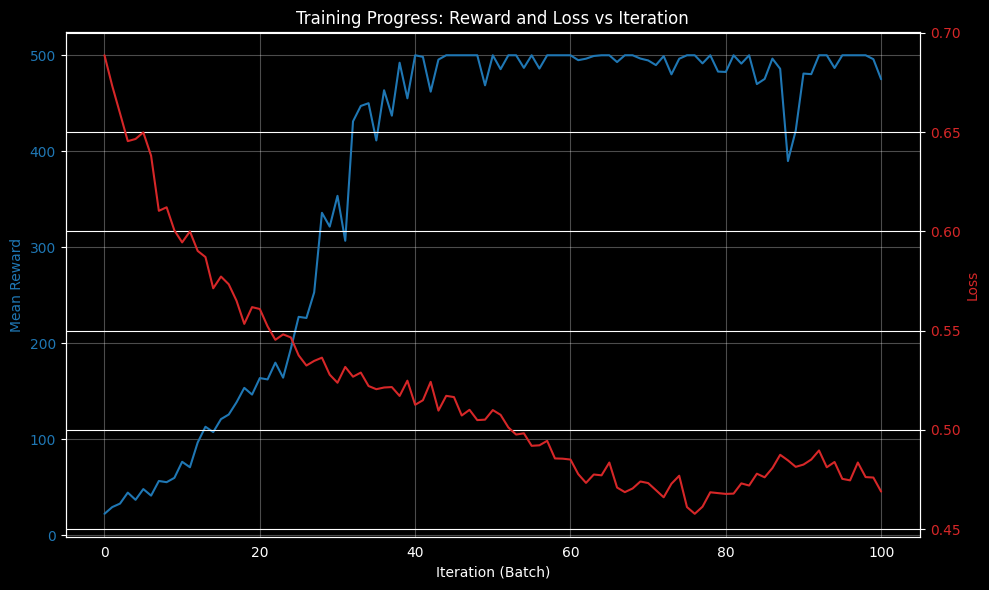

In [42]:
try:
    print("Training started...")
    for iter_no, batch in enumerate(iterate_batches(env, net, BATCH_SIZE)):
        obs_v, acts_v, reward_b, reward_m = filter_batch(batch, PERCENTILE)

        optimizer.zero_grad()
        action_scores = net(obs_v)
        loss = criterion(action_scores, acts_v)
        loss.backward()
        optimizer.step()

        episode_rewards.append(reward_m)
        episode_losses.append(loss.item())

        print(f"Iter {iter_no}: loss={loss.item():.3f}, "
              f"reward_mean={reward_m:.1f}, reward_bound={reward_b:.1f}")

        if iter_no >= MAX_ITER:
            print("Max iterations reached")
            break
finally:
    env.close()

    ## Plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Left y-axis: Reward
    color = 'tab:blue'
    ax1.set_xlabel('Iteration (Batch)')
    ax1.set_ylabel('Mean Reward', color=color)
    ax1.plot(episode_rewards, color=color, label='Reward')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # Right y-axis: Loss
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Loss', color=color)
    ax2.plot(episode_losses, color=color, label='Loss')
    ax2.tick_params(axis='y', labelcolor=color)

    # Title and layout
    plt.title('Training Progress: Reward and Loss vs Iteration')
    fig.tight_layout()
    plt.show()

## Evaluate

![](video/cartpole_trained_agent.gif)

In [43]:
evaluate_policy(net, episodes=2, render=True, save_gif=True, gif_path="video/cartpole_trained_agent.gif")

Starting evaluation with 2 episodes...
Episode 1: Reward = 500.0, Steps = 500
Episode 2: Reward = 500.0, Steps = 500
GIF saved to: video/cartpole_trained_agent.gif
Evaluation Results:
Average Reward: 500.00
Rewards: ['500.0', '500.0']


[500.0, 500.0]

# CartPole (start with rand position)

In [45]:
# CartPole  (standard)
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [46]:
class CartPoleV2(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super(CartPoleV2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.net(x)

In [47]:
def reset_with_random_angle(env, max_angle_deg=10.0, max_position=0.5):
    obs, info = env.reset()
    max_angle_rad = np.deg2rad(max_angle_deg)
    state = env.unwrapped.state.copy()  # [cart_pos, cart_vel, pole_angle, pole_ang_vel]

    # Randomize position and angle
    state[0] = np.random.uniform(-max_position, max_position)  # cart position
    state[2] = np.random.uniform(-max_angle_rad, max_angle_rad)  # pole angle

    # Keep velocities zero (standard practice)
    state[1] = 0.0  # cart velocity
    state[3] = 0.0  # pole angular velocity

    env.unwrapped.state = state
    obs = state.copy()

    return obs, info


def iterate_batches(env, net, batch_size, max_angle_deg=10.0):
    batch = []
    episode_reward = 0.0
    episode_steps = []
    obs, _ = reset_with_random_angle(env, max_angle_deg=max_angle_deg)
    sm = nn.Softmax(dim=1)

    while True:
        obs_v = torch.FloatTensor([obs]).to(device)
        act_probs_v = sm(net(obs_v))
        act_probs = act_probs_v.cpu().detach().numpy()[0]
        action = np.random.choice(len(act_probs), p=act_probs)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        is_done = terminated or truncated

        episode_steps.append({"observation": obs, "action": action})
        episode_reward += reward

        if is_done:
            batch.append({"reward": episode_reward, "steps": episode_steps})
            episode_reward = 0.0
            episode_steps = []
            next_obs, _ = reset_with_random_angle(env, max_angle_deg=max_angle_deg)
            if len(batch) == batch_size:
                yield batch
                batch = []
        obs = next_obs


def filter_batch(batch, percentile):
    rewards = [ep["reward"] for ep in batch]
    reward_bound = np.percentile(rewards, percentile)
    reward_mean = float(np.mean(rewards))

    train_obs = []
    train_act = []
    for ep in batch:
        if ep["reward"] < reward_bound:
            continue
        train_obs.extend([step["observation"] for step in ep["steps"]])
        train_act.extend([step["action"] for step in ep["steps"]])

    obs_v = torch.FloatTensor(train_obs).to(device)
    act_v = torch.LongTensor(train_act).to(device)
    return obs_v, act_v, reward_bound, reward_mean


def evaluate_policy(net, env_name="CartPole-v1", episodes=5, render=True, save_gif=False,
                    gif_path="cartpole_evaluation.gif", max_angle_deg=12.0):
    if save_gif:
        from PIL import Image
        frames = []

    env = gym.make(env_name, render_mode="rgb_array" if save_gif else "human")
    net.eval()

    episode_rewards = []

    print(f"Starting evaluation with {episodes} episodes...")

    for ep in range(episodes):
        obs, _ = reset_with_random_angle(env, max_angle_deg=max_angle_deg)
        episode_reward = 0
        step_count = 0

        while True:
            if render and not save_gif:
                env.render()

            if save_gif:
                frame = env.render()
                if frame is not None:
                    frames.append(Image.fromarray(frame))

            with torch.no_grad():
                obs_v = torch.FloatTensor([obs]).to(device)
                action_probs = torch.softmax(net(obs_v), dim=1)
                action = torch.argmax(action_probs, dim=1).item()

            obs, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            step_count += 1
            is_done = terminated or truncated

            if is_done:
                break

        episode_rewards.append(episode_reward)
        print(f"Episode {ep + 1}: Reward = {episode_reward:.1f}, Steps = {step_count}")

    env.close()

    # Save GIF
    if save_gif and frames:
        # Add extra frames at the end to make it pause
        for _ in range(10):
            frames.append(frames[-1])

        frames[0].save(
            gif_path,
            save_all=True,
            append_images=frames[1:],
            duration=50,  # milliseconds per frame
            loop=0  # infinite loop
        )
        print(f"GIF saved to: {gif_path}")

    avg_reward = np.mean(episode_rewards)
    print(f"Evaluation Results:")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Rewards: {[f'{r:.1f}' for r in episode_rewards]}")

    return episode_rewards


## Training loop

In [48]:
HIDDEN_SIZE = 128
BATCH_SIZE = 16
PERCENTILE = 70
MAX_ITER = 100
TRAIN_MAX_ANGLE = 10.0
EVAL_MAX_ANGLE = 15.0

# setup
env = gym.make("CartPole-v1")
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

net = CartPoleV2(obs_size, HIDDEN_SIZE, n_actions).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

# history
episode_rewards = []
episode_losses = []

Training started...
Iter 0: loss=0.696, reward_mean=15.6, reward_bound=17.0
Iter 1: loss=0.688, reward_mean=17.1, reward_bound=22.5
Iter 2: loss=0.675, reward_mean=24.0, reward_bound=30.0
Iter 3: loss=0.667, reward_mean=27.2, reward_bound=36.0
Iter 4: loss=0.653, reward_mean=21.8, reward_bound=26.5
Iter 5: loss=0.651, reward_mean=31.9, reward_bound=39.0
Iter 6: loss=0.641, reward_mean=32.9, reward_bound=52.5
Iter 7: loss=0.649, reward_mean=27.9, reward_bound=35.0
Iter 8: loss=0.622, reward_mean=32.0, reward_bound=42.5
Iter 9: loss=0.626, reward_mean=40.1, reward_bound=47.0
Iter 10: loss=0.624, reward_mean=37.2, reward_bound=50.0
Iter 11: loss=0.611, reward_mean=27.4, reward_bound=34.0
Iter 12: loss=0.606, reward_mean=34.4, reward_bound=42.5
Iter 13: loss=0.615, reward_mean=32.5, reward_bound=26.0
Iter 14: loss=0.612, reward_mean=35.9, reward_bound=42.5
Iter 15: loss=0.596, reward_mean=45.2, reward_bound=59.5
Iter 16: loss=0.597, reward_mean=44.6, reward_bound=55.0
Iter 17: loss=0.586, 

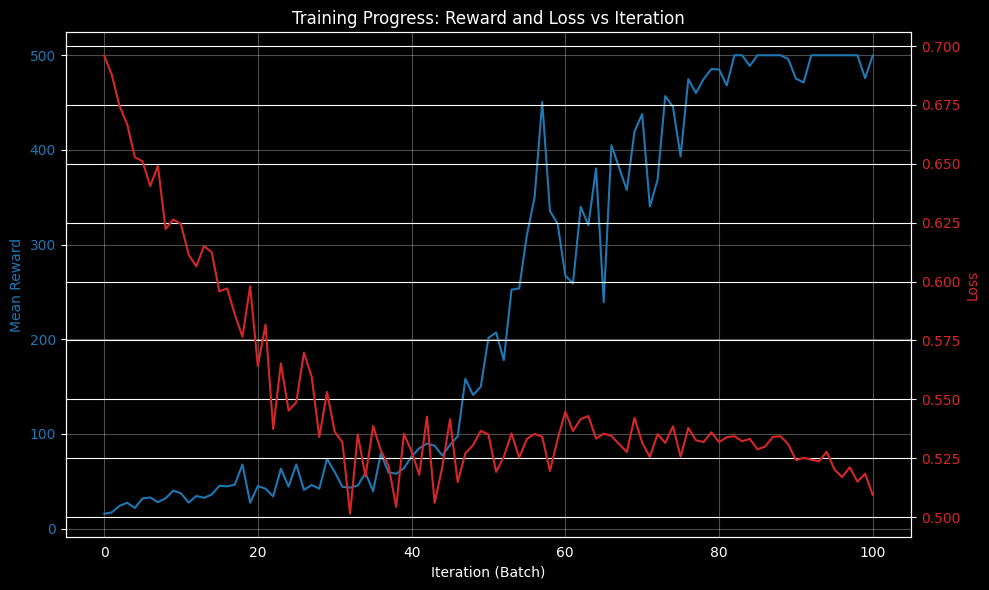

In [49]:
try:
    print("Training started...")
    for iter_no, batch in enumerate(iterate_batches(env, net, BATCH_SIZE, max_angle_deg=TRAIN_MAX_ANGLE)):
        obs_v, acts_v, reward_b, reward_m = filter_batch(batch, PERCENTILE)

        optimizer.zero_grad()
        action_scores = net(obs_v)
        loss = criterion(action_scores, acts_v)
        loss.backward()
        optimizer.step()

        episode_rewards.append(reward_m)
        episode_losses.append(loss.item())

        print(f"Iter {iter_no}: loss={loss.item():.3f}, "
              f"reward_mean={reward_m:.1f}, reward_bound={reward_b:.1f}")

        if iter_no >= MAX_ITER:
            print("Max iterations reached")
            break
finally:
    env.close()

    ## Plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Left y-axis: Reward
    color = 'tab:blue'
    ax1.set_xlabel('Iteration (Batch)')
    ax1.set_ylabel('Mean Reward', color=color)
    ax1.plot(episode_rewards, color=color, label='Reward')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # Right y-axis: Loss
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Loss', color=color)
    ax2.plot(episode_losses, color=color, label='Loss')
    ax2.tick_params(axis='y', labelcolor=color)

    # Title and layout
    plt.title('Training Progress: Reward and Loss vs Iteration')
    fig.tight_layout()
    plt.show()

## Evaluate

![](video/cartpole_trained_agent-2.gif)
![](video/cartpole_trained_agent-2b.gif)

In [51]:
evaluate_policy(net, episodes=2, render=True, save_gif=True, gif_path="video/cartpole_trained_agent-2.gif",
                max_angle_deg=EVAL_MAX_ANGLE)

Starting evaluation with 2 episodes...
Episode 1: Reward = 500.0, Steps = 500
Episode 2: Reward = 500.0, Steps = 500
GIF saved to: video/cartpole_trained_agent-2.gif
Evaluation Results:
Average Reward: 500.00
Rewards: ['500.0', '500.0']


[500.0, 500.0]

In [52]:
evaluate_policy(net, episodes=2, render=True, save_gif=True, gif_path="video/cartpole_trained_agent-2b.gif",
                max_angle_deg=EVAL_MAX_ANGLE * 2)

Starting evaluation with 2 episodes...
Episode 1: Reward = 500.0, Steps = 500
Episode 2: Reward = 1.0, Steps = 1
GIF saved to: video/cartpole_trained_agent-2b.gif
Evaluation Results:
Average Reward: 250.50
Rewards: ['500.0', '1.0']


[500.0, 1.0]

# CartPole (start from bottom)
🚧WIP🚧

Using device: cuda
Training started...
Iter 0: loss=0.622, reward_mean=0.1, reward_bound=0.0
Iter 1: loss=0.687, reward_mean=0.0, reward_bound=0.0
Iter 2: loss=0.493, reward_mean=0.0, reward_bound=0.0
Iter 3: loss=0.635, reward_mean=0.0, reward_bound=0.0
Iter 4: loss=0.260, reward_mean=0.0, reward_bound=0.0
Iter 5: loss=0.377, reward_mean=0.0, reward_bound=0.0
Iter 6: loss=0.123, reward_mean=0.0, reward_bound=0.0
Iter 7: loss=0.238, reward_mean=0.0, reward_bound=0.0
Iter 8: loss=0.234, reward_mean=0.0, reward_bound=0.0
Iter 9: loss=0.048, reward_mean=0.0, reward_bound=0.0
Iter 10: loss=0.033, reward_mean=0.0, reward_bound=0.0
Iter 11: loss=0.022, reward_mean=0.0, reward_bound=0.0
Iter 12: loss=0.014, reward_mean=0.0, reward_bound=0.0
Iter 13: loss=0.009, reward_mean=0.0, reward_bound=0.0


/home/ezio4df/projects/LearningRes/Bk-DeepRLHandsOn-MaximLapan/.venv/lib/python3.13/site-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


Iter 14: loss=0.006, reward_mean=0.0, reward_bound=0.0
Iter 15: loss=0.004, reward_mean=0.0, reward_bound=0.0
Iter 16: loss=0.003, reward_mean=0.0, reward_bound=0.0
Iter 17: loss=0.002, reward_mean=0.0, reward_bound=0.0
Iter 18: loss=0.001, reward_mean=0.0, reward_bound=0.0
Iter 19: loss=0.001, reward_mean=0.0, reward_bound=0.0
Iter 20: loss=0.001, reward_mean=0.0, reward_bound=0.0
Iter 21: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 22: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 23: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 24: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 25: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 26: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 27: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 28: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 29: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 30: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 31: loss=0.000, reward_mean=0.0, reward_bound=0.0
Iter 32: l

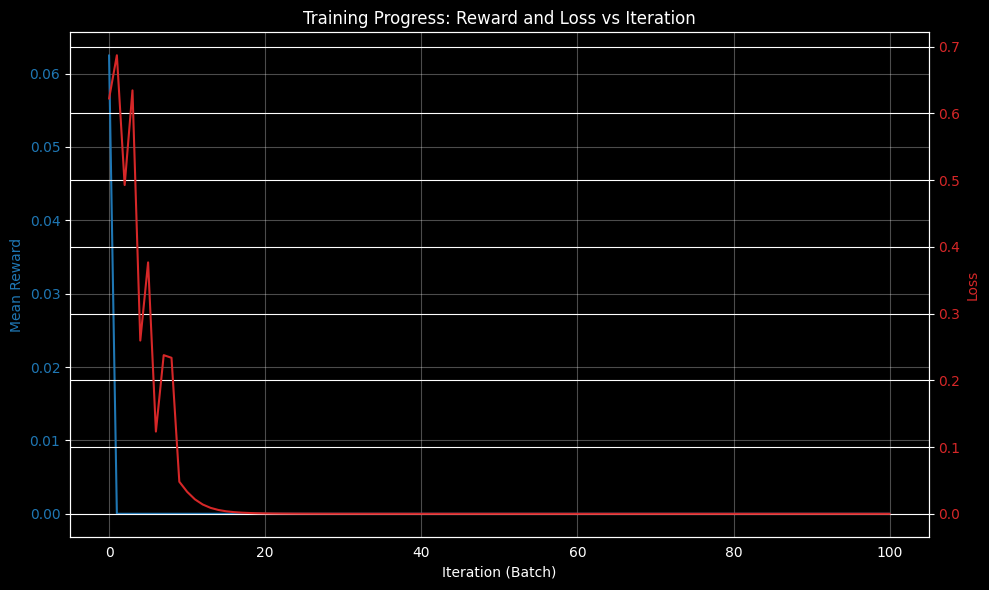

Starting evaluation with 2 episodes...
Episode 1: Reward = 1.0, Steps = 1
Episode 2: Reward = 0.0, Steps = 1
GIF saved to: video/cartpole_trained_agent-3.gif
Evaluation Results:
Average Reward: 0.50
Rewards: ['1.0', '0.0']


[1.0, 0.0]

In [56]:
# # CartPole (start from bottom)

import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class CartPoleDownward(gym.Env):
    def __init__(self):
        self.env = gym.make("CartPole-v1").unwrapped

        # Copy spaces
        self.observation_space = self.env.observation_space
        self.action_space = self.env.action_space

        # Store original parameters
        self.gravity = self.env.gravity
        self.masscart = self.env.masscart
        self.masspole = self.env.masspole
        self.total_mass = self.env.total_mass
        self.length = self.env.length
        self.polemass_length = self.env.polemass_length
        self.force_mag = self.env.force_mag
        self.tau = self.env.tau

    def step(self, action):
        return self.env.step(action)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        # Set state: pole pointing DOWN (angle = pi), zero velocities
        self.env.state = np.array([0.0, 0.0, np.pi, 0.0], dtype=np.float32)
        return self.env.state.copy(), {}

    def render(self):
        return self.env.render()

    def close(self):
        return self.env.close()

def make_downward_cartpole(max_steps=500, render_mode=None):
    base_env = CartPoleDownward()
    if render_mode == "rgb_array":
        base_env.env.render_mode = "rgb_array"
    elif render_mode == "human":
        base_env.env.render_mode = "human"
    return TimeLimit(base_env, max_episode_steps=max_steps)



class CartPoleV3(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super(CartPoleV3, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.net(x)


def reset_with_pole_down(env):
    obs, info = env.reset()

    # override the state to point downward
    state = np.array([0.0, 0.0, np.pi, 0.0], dtype=np.float32)
    env.unwrapped.state = state
    obs = state.copy()

    return obs, info


def iterate_batches(env, net, batch_size):
    batch = []
    episode_reward = 0.0
    episode_steps = []
    obs, _ = reset_with_pole_down(env)
    sm = nn.Softmax(dim=1)

    while True:
        obs_v = torch.FloatTensor([obs]).to(device)
        act_probs_v = sm(net(obs_v))
        act_probs = act_probs_v.cpu().detach().numpy()[0]
        action = np.random.choice(len(act_probs), p=act_probs)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        is_done = terminated or truncated

        episode_steps.append({"observation": obs, "action": action})
        episode_reward += reward

        if is_done:
            batch.append({"reward": episode_reward, "steps": episode_steps})
            episode_reward = 0.0
            episode_steps = []
            next_obs, _ = reset_with_pole_down(env)
            if len(batch) == batch_size:
                yield batch
                batch = []
        obs = next_obs


def filter_batch(batch, percentile):
    rewards = [ep["reward"] for ep in batch]
    reward_bound = np.percentile(rewards, percentile)
    reward_mean = float(np.mean(rewards))

    train_obs = []
    train_act = []
    for ep in batch:
        if ep["reward"] < reward_bound:
            continue
        train_obs.extend([step["observation"] for step in ep["steps"]])
        train_act.extend([step["action"] for step in ep["steps"]])

    obs_v = torch.FloatTensor(train_obs).to(device)
    act_v = torch.LongTensor(train_act).to(device)
    return obs_v, act_v, reward_bound, reward_mean


def evaluate_policy(net, env_name="CartPole-v1", episodes=5, render=True, save_gif=False,
                    gif_path="cartpole_evaluation.gif"):
    if save_gif:
        frames = []

    env = make_downward_cartpole(max_steps=500, render_mode="rgb_array" if save_gif else "human")
    net.eval()

    episode_rewards = []

    print(f"Starting evaluation with {episodes} episodes...")

    for ep in range(episodes):
        obs, _ = reset_with_pole_down(env)
        episode_reward = 0
        step_count = 0

        while True:
            if render and not save_gif:
                env.render()

            if save_gif:
                frame = env.render()
                if frame is not None:
                    frames.append(Image.fromarray(frame))

            with torch.no_grad():
                obs_v = torch.FloatTensor([obs]).to(device)
                action_probs = torch.softmax(net(obs_v), dim=1)
                action = torch.argmax(action_probs, dim=1).item()

            obs, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            step_count += 1
            is_done = terminated or truncated

            if is_done:
                break

        episode_rewards.append(episode_reward)
        print(f"Episode {ep + 1}: Reward = {episode_reward:.1f}, Steps = {step_count}")

    env.close()

    if save_gif and frames:
        for _ in range(10):
            frames.append(frames[-1])

        frames[0].save(
            gif_path,
            save_all=True,
            append_images=frames[1:],
            duration=50,
            loop=0
        )
        print(f"GIF saved to: {gif_path}")

    avg_reward = np.mean(episode_rewards)
    print(f"Evaluation Results:")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Rewards: {[f'{r:.1f}' for r in episode_rewards]}")

    return episode_rewards


# ## Training loop

HIDDEN_SIZE = 128
BATCH_SIZE = 16
PERCENTILE = 70
MAX_ITER = 100

# setup
env = make_downward_cartpole(max_steps=500)
obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

net = CartPoleV3(obs_size, HIDDEN_SIZE, n_actions).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

# history
episode_rewards = []
episode_losses = []

try:
    print("Training started...")
    for iter_no, batch in enumerate(iterate_batches(env, net, BATCH_SIZE)):
        obs_v, acts_v, reward_b, reward_m = filter_batch(batch, PERCENTILE)

        optimizer.zero_grad()
        action_scores = net(obs_v)
        loss = criterion(action_scores, acts_v)
        loss.backward()
        optimizer.step()

        episode_rewards.append(reward_m)
        episode_losses.append(loss.item())

        print(f"Iter {iter_no}: loss={loss.item():.3f}, "
              f"reward_mean={reward_m:.1f}, reward_bound={reward_b:.1f}")

        if iter_no >= MAX_ITER:
            print("Max iterations reached")
            break
finally:
    env.close()

    ## Plot
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Iteration (Batch)')
    ax1.set_ylabel('Mean Reward', color=color)
    ax1.plot(episode_rewards, color=color, label='Reward')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Loss', color=color)
    ax2.plot(episode_losses, color=color, label='Loss')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Training Progress: Reward and Loss vs Iteration')
    fig.tight_layout()
    plt.show()

# ## Evaluate

os.makedirs("video", exist_ok=True)
evaluate_policy(net, episodes=2, render=True, save_gif=True, gif_path="video/cartpole_trained_agent-3.gif")